# Stage 1 · Step 2 — Feature Extraction

**CVLAB Summer Project — *Flow Matching as a Layer*** · University of Haifa · Dr. Simon Korman

---

This is the pivot point of Stage 1. The assignment requires the encoders to be **frozen**,
run **exactly once**, and their outputs **cached** — with all classifier training done on
the cache. After this notebook, nothing in the project touches an image or an encoder
again: steps 3, 4 and 5 read plain tensors.

That constraint is not bookkeeping. It is what makes the later comparison honest:

- The linear probe (step 3) and the prototype baseline (step 4) read the **same bytes**,
  so any accuracy gap between them comes from the classifier design rather than from one
  of them happening to get better features.
- A 27-run hyperparameter sweep becomes minutes instead of hours, because the expensive
  part happened once, here.
- Stage 2's Flow-Matching layer will be dropped into exactly this position, on exactly
  these features — which is the only way its contribution can be isolated.

### What gets extracted

| Encoder | Feature dim | DTD | FGVC-Aircraft |
|---|---|---|---|
| ResNet-18 (ImageNet-1K) | 512 | yes | yes |
| DINOv2 ViT-S/14 | 384 | — | yes |

Three (encoder, dataset) pairs × three splits = **9 cache files**, covering 25,640 image
forward passes.

### What this notebook produces

| # | Section | Output |
|---|---------|--------|
| 1 | Encoder inventory & frozen-parameter proof | `tables/encoder_inventory.csv` |
| 2 | Preprocessing pipeline, visualised | `plots/preprocessing_pipeline.png` |
| 3 | Extraction plan | `tables/extraction_plan.csv` |
| 4 | **Extraction** | 9 files in `Stage_1/features/`, `tables/extraction_log.csv`, `plots/extraction_throughput.png` |
| 5 | Cache verification | `tables/cache_verification.csv` |
| 6 | Feature statistics | `tables/feature_statistics.csv`, `plots/feature_norms.png` |
| 7 | Intrinsic dimensionality (PCA) | `tables/pca_variance.csv`, `plots/pca_explained_variance.png` |
| 8 | Class separability preview | `tables/class_separability.csv`, `plots/class_separability.png` |
| 9 | Copyright-banner ablation | `tables/banner_ablation.csv`, `plots/banner_ablation.png` |

> **Runtime:** ~8–10 minutes, GPU-bound only briefly — the real cost is CPU-side JPEG
> decoding. Re-running is near-instant: existing caches are reused unless
> `FORCE_REEXTRACT = True`.

## 0 · Setup

Everything mechanical lives in the `cvlab` package — encoder construction, the
preprocessing rules, the extraction loop, and the cache format. This notebook decides
*what* to extract and interrogates the result.

In [1]:
"""Stage 1 / Step 2 — run the frozen encoders once and cache their features."""
from __future__ import annotations

import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from torchvision import transforms

from cvlab.data import DATASET_SPECS, SPLITS, image_files, load_split
from cvlab.data import labels as cvlab_labels
from cvlab.encoders import (
    AIRCRAFT_BANNER_PX,
    ENCODER_SPECS,
    CropBottomBanner,
    build_encoder,
    preprocessing_for,
)
from cvlab.features import (
    cache_exists,
    extract_features,
    feature_path,
    load_features,
    save_features,
)
from cvlab.paths import FEATURES_ROOT, step_dirs
from cvlab.plotting import DATASET_COLORS, ENCODER_COLORS, ArtifactWriter, apply_style

apply_style()
art = ArtifactWriter(*step_dirs("02_feature_extraction"))

# --- Run configuration -----------------------------------------------------
# The three (encoder, dataset) pairs the assignment mandates.
COMBOS: list[tuple[str, str]] = [
    ("resnet18", "DTD"),
    ("resnet18", "FGVC-Aircraft"),
    ("dinov2", "FGVC-Aircraft"),
]

BATCH_SIZE = 64      # measured peak VRAM 0.46 GB - comfortably inside this GPU's 4 GB
NUM_WORKERS = 4      # ~2x faster than 0 here; safe because every transform is picklable
CROP_BANNER = True   # remove the 20 px FGVC-Aircraft copyright strip (finding from step 01)
FORCE_REEXTRACT = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
FEATURES_ROOT.mkdir(parents=True, exist_ok=True)

print(f"device        : {DEVICE}")
if DEVICE == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"gpu           : {props.name} ({props.total_memory / 1024 ** 3:.1f} GB)")
else:
    print("WARNING: no GPU detected - extraction will be slow but results are identical")
print(f"batch size    : {BATCH_SIZE}")
print(f"workers       : {NUM_WORKERS}")
print(f"banner crop   : {CROP_BANNER}")
print(f"cache dir     : {FEATURES_ROOT}")

device        : cuda
gpu           : NVIDIA GeForce RTX 3050 Laptop GPU (4.0 GB)
batch size    : 64
workers       : 4
banner crop   : True
cache dir     : C:\Users\youse\Project in Computer Vision\ProjectInComputerVision\Stage_1\features


## 1 · Encoder inventory

Both encoders are built through `cvlab.encoders.build_encoder`, which freezes every
parameter and switches the model to `eval()` before returning it. The builder asserts that
zero parameters remain trainable, so "the encoders are frozen" is enforced in code rather
than asserted in prose.

Two details the assignment is specific about:

- **ResNet-18** must yield the *512-dimensional representation before the final
  classification layer*. We get it by replacing `model.fc` with `nn.Identity()`, so the
  forward pass returns the vector that used to feed the classifier.
- **DINOv2 ViT-S/14** must yield the *final class-token representation*. Calling the hub
  model returns exactly that, 384-dimensional.

`eval()` matters beyond convention: it puts BatchNorm in inference mode, so ResNet-18 uses
its stored ImageNet running statistics rather than statistics computed from our batches. In
train mode the features would depend on how images happened to be grouped into batches,
which would make the cache non-reproducible.

In [2]:
encoders: dict[str, dict] = {}
inventory_rows = []

for name in ("resnet18", "dinov2"):
    spec = ENCODER_SPECS[name]
    t0 = time.perf_counter()
    model, base_transform = build_encoder(name)
    load_s = time.perf_counter() - t0

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # Confirm the advertised output dimension with a real forward pass.
    with torch.no_grad():
        probe_out = model(torch.randn(2, 3, 224, 224))

    encoders[name] = {"model": model, "transform": base_transform, "spec": spec}
    inventory_rows.append({
        "encoder": spec.display_name,
        "key": name,
        "checkpoint": spec.checkpoint,
        "feature_dim_expected": spec.feature_dim,
        "feature_dim_measured": int(probe_out.shape[1]),
        "params_M": round(total_params / 1e6, 2),
        "trainable_params": trainable_params,
        "training_mode": model.training,
        "load_s": round(load_s, 2),
        "datasets": ", ".join(spec.datasets),
    })

inventory_df = pd.DataFrame(inventory_rows)
art.table(inventory_df, "encoder_inventory")

assert (inventory_df["trainable_params"] == 0).all(), "an encoder is not frozen"
assert (inventory_df["feature_dim_expected"] == inventory_df["feature_dim_measured"]).all()
assert not inventory_df["training_mode"].any(), "an encoder is still in train mode"
print("\nboth encoders frozen, in eval mode, and producing the expected dimensions")
inventory_df

C:\Users\youse/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\youse/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\youse/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


  saved table -> tables/encoder_inventory.csv  (2 rows)

both encoders frozen, in eval mode, and producing the expected dimensions


,encoder,key,checkpoint,feature_dim_expected,feature_dim_measured,params_M,trainable_params,training_mode,load_s,datasets
0,ResNet-18,resnet18,torchvision IMAGENET1K_V1,512,512,11.18,0,False,0.32,"DTD, FGVC-Aircraft"
1,DINOv2 ViT-S/14,dinov2,facebookresearch/dinov2 : dinov2_vits14,384,384,22.06,0,False,1.44,FGVC-Aircraft


## 2 · Preprocessing

The assignment requires *"the preprocessing associated with each checkpoint"*. For
ResNet-18 that is `weights.transforms()` — the transform torchvision recorded alongside the
weights — rather than a hand-written resize/crop/normalise that merely looks equivalent.
For DINOv2 it is the published evaluation recipe (bicubic resize to 256, centre-crop 224,
ImageNet normalisation).

**One dataset-specific addition.** Step 01 established that every FGVC-Aircraft image has a
20-pixel copyright banner burned into its bottom edge. `CropBottomBanner` removes it
*before* the checkpoint transform runs. This cleans the input image; it does not alter the
checkpoint's own preprocessing. Section 9 measures how much difference it makes.

The figure below traces one image of each dataset through the pipeline, so what the encoder
actually receives is visible rather than inferred. The normalisation step is omitted from
the display because normalised tensors do not render meaningfully as images.

In [3]:
for name, bundle in encoders.items():
    print(f"{ENCODER_SPECS[name].display_name}:")
    print(f"  {bundle['transform']}".replace("\n", "\n  "))
    print()

print("Dataset-adjusted transforms actually used:")
for enc, ds_name in COMBOS:
    tf = preprocessing_for(encoders[enc]["transform"], ds_name, crop_banner=CROP_BANNER)
    has_crop = "CropBottomBanner" in repr(tf)
    print(f"  {enc:9s} / {ds_name:14s} banner crop: {has_crop}")

ResNet-18:
  ImageClassification(
      crop_size=[224]
      resize_size=[256]
      mean=[0.485, 0.456, 0.406]
      std=[0.229, 0.224, 0.225]
      interpolation=InterpolationMode.BILINEAR
  )

DINOv2 ViT-S/14:
  Compose(
      Resize(size=256, interpolation=bicubic, max_size=None, antialias=True)
      CenterCrop(size=(224, 224))
      ToTensor()
      Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
  )

Dataset-adjusted transforms actually used:
  resnet18  / DTD            banner crop: False
  resnet18  / FGVC-Aircraft  banner crop: True
  dinov2    / FGVC-Aircraft  banner crop: True


  saved plot  -> plots/preprocessing_pipeline.png


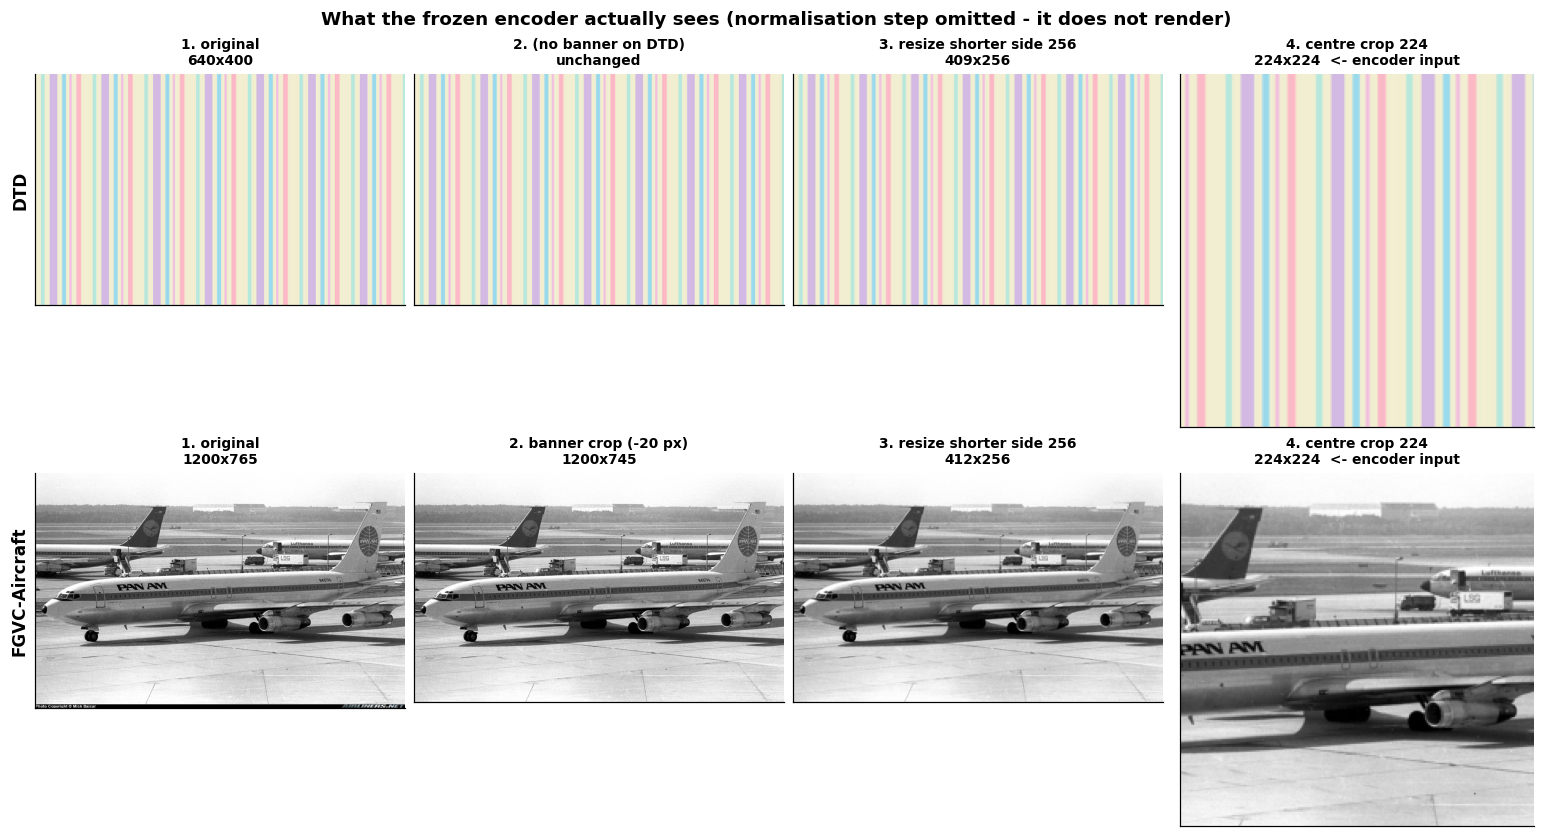

In [4]:
# Rebuild the resize/crop steps explicitly so the intermediate stages can be displayed.
# These mirror the checkpoint transforms (resize shorter side 256, centre crop 224); the
# real extraction below uses the checkpoint transform itself, not this reconstruction.
_resize = transforms.Resize(256)
_crop = transforms.CenterCrop(224)

examples = {
    "DTD": image_files(load_split("DTD", "test"))[7],
    "FGVC-Aircraft": image_files(load_split("FGVC-Aircraft", "test"))[3],
}

fig, axes = plt.subplots(2, 4, figsize=(14, 7.5), layout="constrained")
for row, (ds_name, path) in enumerate(examples.items()):
    original = Image.open(path).convert("RGB")
    banner_cropped = (CropBottomBanner(AIRCRAFT_BANNER_PX)(original)
                      if ds_name == "FGVC-Aircraft" else original)
    resized = _resize(banner_cropped)
    cropped = _crop(resized)

    stages = [
        (original, f"1. original\n{original.size[0]}x{original.size[1]}"),
        (banner_cropped,
         f"2. banner crop (-{AIRCRAFT_BANNER_PX} px)\n{banner_cropped.size[0]}x{banner_cropped.size[1]}"
         if ds_name == "FGVC-Aircraft" else "2. (no banner on DTD)\nunchanged"),
        (resized, f"3. resize shorter side 256\n{resized.size[0]}x{resized.size[1]}"),
        (cropped, f"4. centre crop 224\n{cropped.size[0]}x{cropped.size[1]}  <- encoder input"),
    ]
    for col, (img, title) in enumerate(stages):
        ax = axes[row, col]
        ax.imshow(img)
        ax.set_title(title, fontsize=9)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        # Anchor each panel to the top of its cell so the differing aspect ratios
        # (wide originals vs. the square 224 crop) still line up along one baseline.
        ax.set_anchor("N")
    axes[row, 0].set_ylabel(ds_name, fontsize=11, fontweight="bold")

fig.suptitle("What the frozen encoder actually sees (normalisation step omitted - it does not render)",
             fontsize=12, fontweight="bold")
art.figure(fig, "preprocessing_pipeline")
plt.show()

## 3 · Extraction plan

Nine cache files. Listing them before running makes the scope explicit and gives the
verification step in section 5 something definitive to check against.

In [5]:
plan_rows = []
for enc, ds_name in COMBOS:
    for split in SPLITS:
        plan_rows.append({
            "encoder": enc,
            "dataset": ds_name,
            "split": split,
            "n_images": DATASET_SPECS[ds_name]["split_sizes"][split],
            "feature_dim": ENCODER_SPECS[enc].feature_dim,
            "cache_file": feature_path(enc, ds_name, split).name,
            "already_cached": cache_exists(enc, ds_name, split),
        })

plan_df = pd.DataFrame(plan_rows)
art.table(plan_df, "extraction_plan")

print(f"{len(plan_df)} cache files, {plan_df['n_images'].sum():,} image forward passes total")
print(f"already cached: {int(plan_df['already_cached'].sum())}/{len(plan_df)}")
plan_df

  saved table -> tables/extraction_plan.csv  (9 rows)
9 cache files, 25,640 image forward passes total
already cached: 0/9


,encoder,dataset,split,n_images,feature_dim,cache_file,already_cached
0,resnet18,DTD,train,1880,512,resnet18__dtd__train.pt,False
1,resnet18,DTD,val,1880,512,resnet18__dtd__val.pt,False
2,resnet18,DTD,test,1880,512,resnet18__dtd__test.pt,False
3,resnet18,FGVC-Aircraft,train,3334,512,resnet18__fgvc_aircraft__train.pt,False
4,resnet18,FGVC-Aircraft,val,3333,512,resnet18__fgvc_aircraft__val.pt,False
5,resnet18,FGVC-Aircraft,test,3333,512,resnet18__fgvc_aircraft__test.pt,False
6,dinov2,FGVC-Aircraft,train,3334,384,dinov2__fgvc_aircraft__train.pt,False
7,dinov2,FGVC-Aircraft,val,3333,384,dinov2__fgvc_aircraft__val.pt,False
8,dinov2,FGVC-Aircraft,test,3333,384,dinov2__fgvc_aircraft__test.pt,False


## 4 · Extraction

The main event. For each (encoder, dataset, split) the dataset is constructed **with the
encoder's transform already attached**, so the DataLoader hands the model finished tensors
and no wrapper class is needed.

That detail is what lets `num_workers=4` work here at all. Windows starts DataLoader
workers with the `spawn` method, which pickles the dataset and its transform — and a class
defined inside a function cannot be pickled. Because `CropBottomBanner` lives at module
level in the installed `cvlab` package, pickling succeeds and extraction runs about **twice
as fast** (measured: 58 img/s versus 28 img/s single-threaded).

The bottleneck is CPU-side JPEG decoding and resizing, not the GPU. Measured on this
machine for FGVC-Aircraft: reading files from disk runs at ~2,360 img/s, JPEG decode at
~112 img/s, and the resize/crop transform at ~122 img/s. The GPU forward pass is nowhere
near the critical path — which is also why batch size barely matters, and why 64 was kept
(peak VRAM 0.46 GB, leaving the 4 GB card almost empty).

In [6]:
extraction_log = []

for enc, ds_name in COMBOS:
    spec = ENCODER_SPECS[enc]
    model = encoders[enc]["model"]
    transform = preprocessing_for(encoders[enc]["transform"], ds_name, crop_banner=CROP_BANNER)
    print(f"=== {spec.display_name} / {ds_name} ===")

    for split in SPLITS:
        path = feature_path(enc, ds_name, split)
        if path.exists() and not FORCE_REEXTRACT:
            bundle = load_features(enc, ds_name, split)
            print(f"  {split:5s} cached  {tuple(bundle.features.shape)}  (skipping)")
            extraction_log.append({
                "encoder": enc, "dataset": ds_name, "split": split,
                "n_images": len(bundle), "feature_dim": bundle.dim,
                "elapsed_s": bundle.meta.get("elapsed_s", float("nan")),
                "images_per_s": bundle.meta.get("images_per_s", float("nan")),
                "peak_vram_GB": float("nan"), "status": "reused",
            })
            continue

        dataset = load_split(ds_name, split, transform=transform)
        if DEVICE == "cuda":
            torch.cuda.reset_peak_memory_stats()

        feats, labels_t, elapsed = extract_features(
            model, dataset, device=DEVICE, batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS, label=f"{split:5s} ",
        )
        peak_vram = (torch.cuda.max_memory_allocated() / 1024 ** 3) if DEVICE == "cuda" else float("nan")

        save_features(
            feats, labels_t, list(dataset.classes),
            encoder=enc, dataset=ds_name, split=split,
            transform=transform, crop_banner=(CROP_BANNER and ds_name == "FGVC-Aircraft"),
            device=DEVICE, elapsed_s=elapsed,
        )
        print(f"  {split:5s} saved   {tuple(feats.shape)}  in {elapsed:.1f}s  "
              f"({len(feats) / elapsed:.0f} img/s, peak VRAM {peak_vram:.2f} GB)")

        extraction_log.append({
            "encoder": enc, "dataset": ds_name, "split": split,
            "n_images": len(feats), "feature_dim": feats.shape[1],
            "elapsed_s": round(elapsed, 2), "images_per_s": round(len(feats) / elapsed, 1),
            "peak_vram_GB": round(peak_vram, 3), "status": "extracted",
        })

    # Free the GPU before the next encoder loads.
    model.cpu()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

log_df = pd.DataFrame(extraction_log)
art.table(log_df, "extraction_log")

total_imgs = int(log_df["n_images"].sum())
total_time = float(log_df.loc[log_df["status"] == "extracted", "elapsed_s"].sum())
print(f"\n{total_imgs:,} images through the encoders in {total_time / 60:.1f} min")
log_df

=== ResNet-18 / DTD ===


    train   23%  batch 7/30  ~19 img/s


    train   47%  batch 14/30  ~37 img/s


    train   70%  batch 21/30  ~54 img/s


    train   93%  batch 28/30  ~69 img/s
    train  100%  batch 30/30  ~73 img/s


...

    test    49%  batch 26/53  ~46 img/s


    test    74%  batch 39/53  ~58 img/s


    test    98%  batch 52/53  ~66 img/s
    test   100%  batch 53/53  ~67 img/s


  test  saved   (3333, 384)  in 51.7s  (64 img/s, peak VRAM 0.38 GB)
  saved table -> tables/extraction_log.csv  (9 rows)

25,640 images through the encoders in 6.0 min


,encoder,dataset,split,n_images,feature_dim,elapsed_s,images_per_s,peak_vram_GB,status
0,resnet18,DTD,train,1880,512,27.05,69.5,0.460,extracted
1,resnet18,DTD,val,1880,512,25.50,73.7,0.460,extracted
2,resnet18,DTD,test,1880,512,25.09,74.9,0.460,extracted
3,resnet18,FGVC-Aircraft,train,3334,512,43.02,77.5,0.460,extracted
4,resnet18,FGVC-Aircraft,val,3333,512,40.68,81.9,0.460,extracted
5,resnet18,FGVC-Aircraft,test,3333,512,42.31,78.8,0.460,extracted
6,dinov2,FGVC-Aircraft,train,3334,384,51.66,64.5,0.385,extracted
7,dinov2,FGVC-Aircraft,val,3333,384,53.88,61.9,0.385,extracted
8,dinov2,FGVC-Aircraft,test,3333,384,51.74,64.4,0.385,extracted


  saved plot  -> plots/extraction_throughput.png


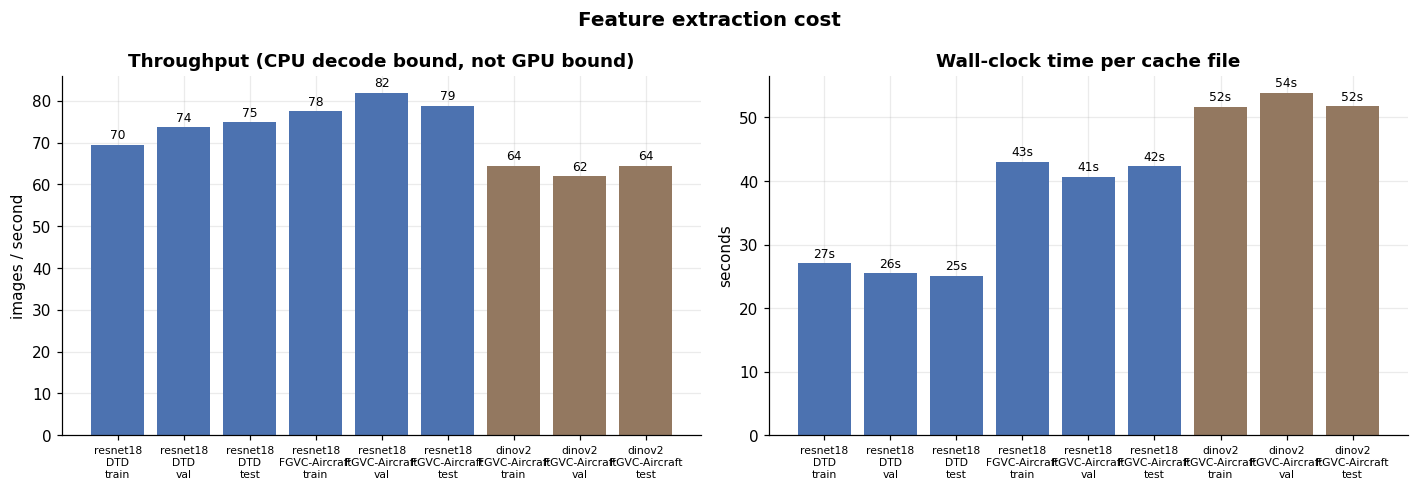

In [7]:
extracted = log_df[log_df["status"] == "extracted"]
if len(extracted):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    combo_labels = [f"{r.encoder}\n{r.dataset}\n{r.split}" for r in extracted.itertuples()]
    colors = [ENCODER_COLORS[r.encoder] for r in extracted.itertuples()]

    bars = axes[0].bar(range(len(extracted)), extracted["images_per_s"], color=colors)
    axes[0].bar_label(bars, fmt="%.0f", padding=2, fontsize=8)
    axes[0].set_xticks(range(len(extracted)))
    axes[0].set_xticklabels(combo_labels, fontsize=7)
    axes[0].set_ylabel("images / second")
    axes[0].set_title("Throughput (CPU decode bound, not GPU bound)")

    bars = axes[1].bar(range(len(extracted)), extracted["elapsed_s"], color=colors)
    axes[1].bar_label(bars, fmt="%.0fs", padding=2, fontsize=8)
    axes[1].set_xticks(range(len(extracted)))
    axes[1].set_xticklabels(combo_labels, fontsize=7)
    axes[1].set_ylabel("seconds")
    axes[1].set_title("Wall-clock time per cache file")

    fig.suptitle("Feature extraction cost", fontsize=13, fontweight="bold")
    fig.tight_layout()
    art.figure(fig, "extraction_throughput")
    plt.show()
else:
    print("all caches were reused - nothing to plot")

## 5 · Cache verification

Reload all nine files from disk and check them against the dataset definitions. Reloading
rather than reusing the in-memory tensors is deliberate: it verifies the round-trip through
`torch.save`/`torch.load`, which is what steps 3–5 will actually depend on.

Checked per file: sample count, feature dimension, class count, no NaNs or infinities,
label range, and that the cached labels are **identical** to the dataset's own labels in the
same order. That last one guards against the silent catastrophe of features and labels
drifting out of alignment — which would produce a model that trains happily and scores at
chance.

In [8]:
verify_rows = []
for enc, ds_name in COMBOS:
    for split in SPLITS:
        bundle = load_features(enc, ds_name, split)
        spec = DATASET_SPECS[ds_name]
        reference = load_split(ds_name, split)          # no transform: labels only

        labels_match = torch.equal(bundle.labels, torch.tensor(cvlab_labels(reference)))
        finite = bool(torch.isfinite(bundle.features).all())

        verify_rows.append({
            "encoder": enc, "dataset": ds_name, "split": split,
            "n_samples": len(bundle),
            "n_expected": spec["split_sizes"][split],
            "feature_dim": bundle.dim,
            "dim_expected": ENCODER_SPECS[enc].feature_dim,
            "n_classes": bundle.n_classes,
            "labels_match_dataset": labels_match,
            "all_finite": finite,
            "label_range_ok": int(bundle.labels.min()) == 0
                              and int(bundle.labels.max()) == spec["n_classes"] - 1,
            "banner_cropped": bundle.meta.get("crop_banner"),
            "size_MB": round(feature_path(enc, ds_name, split).stat().st_size / 1024 ** 2, 1),
        })

verify_df = pd.DataFrame(verify_rows)
verify_df["status"] = np.where(
    (verify_df["n_samples"] == verify_df["n_expected"])
    & (verify_df["feature_dim"] == verify_df["dim_expected"])
    & verify_df["labels_match_dataset"] & verify_df["all_finite"] & verify_df["label_range_ok"],
    "PASS", "FAIL",
)
art.table(verify_df, "cache_verification")

n_fail = int((verify_df["status"] == "FAIL").sum())
print(f"\n{len(verify_df) - n_fail}/{len(verify_df)} cache files verified")
print(f"total cache size: {verify_df['size_MB'].sum():.1f} MB")
assert n_fail == 0, "cache verification FAILED - see table"
verify_df

  saved table -> tables/cache_verification.csv  (9 rows)

9/9 cache files verified
total cache size: 45.3 MB


,encoder,dataset,split,n_samples,n_expected,feature_dim,dim_expected,n_classes,labels_match_dataset,all_finite,label_range_ok,banner_cropped,size_MB,status
0,resnet18,DTD,train,1880,1880,512,512,47,True,True,True,False,3.7,PASS
1,resnet18,DTD,val,1880,1880,512,512,47,True,True,True,False,3.7,PASS
2,resnet18,DTD,test,1880,1880,512,512,47,True,True,True,False,3.7,PASS
3,resnet18,FGVC-Aircraft,train,3334,3334,512,512,100,True,True,True,True,6.5,PASS
4,resnet18,FGVC-Aircraft,val,3333,3333,512,512,100,True,True,True,True,6.5,PASS
5,resnet18,FGVC-Aircraft,test,3333,3333,512,512,100,True,True,True,True,6.5,PASS
6,dinov2,FGVC-Aircraft,train,3334,3334,384,384,100,True,True,True,True,4.9,PASS
7,dinov2,FGVC-Aircraft,val,3333,3333,384,384,100,True,True,True,True,4.9,PASS
8,dinov2,FGVC-Aircraft,test,3333,3333,384,384,100,True,True,True,True,4.9,PASS


## 6 · Feature statistics

The two encoders produce geometrically very different vectors, and knowing how is directly
useful later.

**ResNet-18** features come straight out of a ReLU followed by global average pooling, so
every component is **non-negative** and many are exactly zero. **DINOv2** features are a
transformer CLS token with no such constraint, so they are signed and dense.

The consequence that matters most: the two encoders' features live at **completely
different scales**. That is precisely why the prototype baseline in step 4 must
L2-normalise before averaging, and why any plot mixing raw features with unit-norm
prototypes would be meaningless — the prototypes would collapse into a tiny ball near the
origin while the features sat far out. Establishing the numbers here means that decision is
evidence-based rather than a convention copied from somewhere.

In [9]:
stat_rows = []
feature_cache: dict[tuple[str, str, str], object] = {}

for enc, ds_name in COMBOS:
    for split in SPLITS:
        bundle = load_features(enc, ds_name, split)
        feature_cache[(enc, ds_name, split)] = bundle
        x = bundle.features
        norms = x.norm(dim=1)
        stat_rows.append({
            "encoder": enc, "dataset": ds_name, "split": split,
            "dim": bundle.dim,
            "norm_mean": round(float(norms.mean()), 2),
            "norm_std": round(float(norms.std()), 2),
            "norm_min": round(float(norms.min()), 2),
            "norm_max": round(float(norms.max()), 2),
            "value_min": round(float(x.min()), 3),
            "value_max": round(float(x.max()), 3),
            "pct_exact_zero": round(100 * float((x == 0).float().mean()), 1),
            "pct_negative": round(100 * float((x < 0).float().mean()), 1),
        })

stats_df = pd.DataFrame(stat_rows)
art.table(stats_df, "feature_statistics")
stats_df

  saved table -> tables/feature_statistics.csv  (9 rows)


,encoder,dataset,split,dim,norm_mean,norm_std,norm_min,norm_max,value_min,value_max,pct_exact_zero,pct_negative
0,resnet18,DTD,train,512,23.61,5.24,9.42,54.35,0.000,25.662,7.5,0.0
1,resnet18,DTD,val,512,23.59,5.09,10.70,41.17,0.000,15.692,7.6,0.0
2,resnet18,DTD,test,512,23.75,5.16,11.29,54.50,0.000,29.737,7.3,0.0
3,resnet18,FGVC-Aircraft,train,512,28.98,2.62,21.84,39.90,0.000,10.672,0.9,0.0
4,resnet18,FGVC-Aircraft,val,512,28.91,2.65,15.84,43.12,0.000,10.724,0.9,0.0
5,resnet18,FGVC-Aircraft,test,512,28.87,2.58,20.08,41.78,0.000,10.294,0.9,0.0
6,dinov2,FGVC-Aircraft,train,384,49.64,0.77,46.93,51.99,-12.923,12.723,0.0,50.3
7,dinov2,FGVC-Aircraft,val,384,49.68,0.79,47.07,52.13,-12.417,12.841,0.0,50.3
8,dinov2,FGVC-Aircraft,test,384,49.67,0.79,46.05,52.15,-12.309,12.055,0.0,50.4


  saved plot  -> plots/feature_norms.png


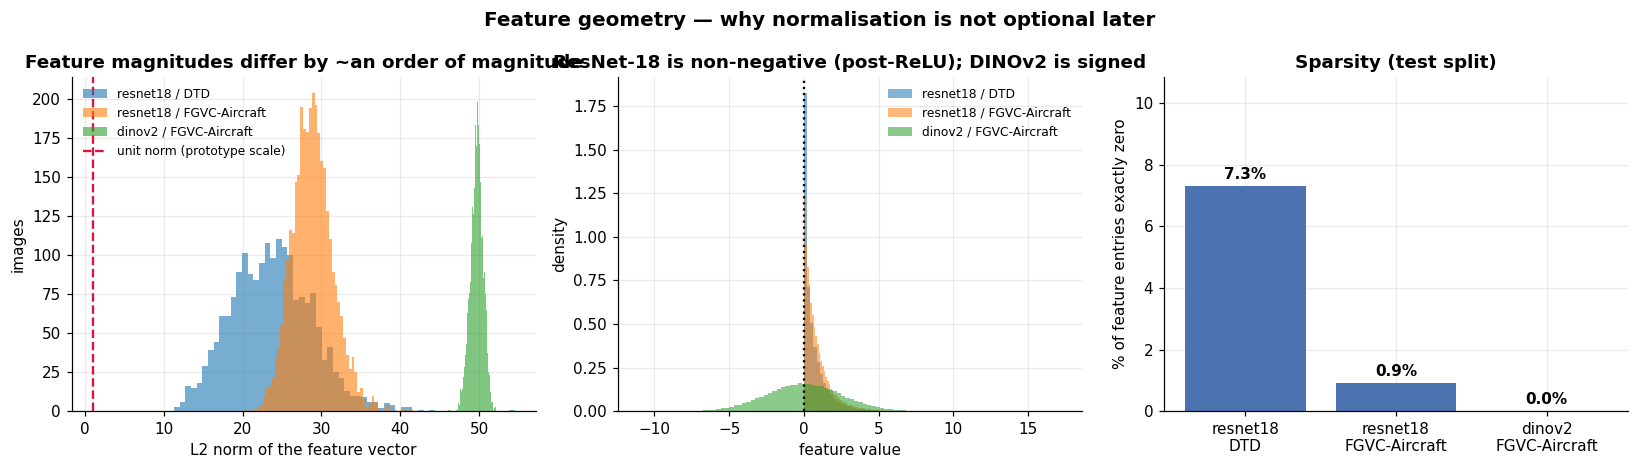

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

# (a) L2 norm distributions on the test split
ax = axes[0]
for enc, ds_name in COMBOS:
    bundle = feature_cache[(enc, ds_name, "test")]
    ax.hist(bundle.features.norm(dim=1).numpy(), bins=60, alpha=0.6,
            label=f"{enc} / {ds_name}")
ax.axvline(1.0, color="crimson", ls="--", lw=1.5, label="unit norm (prototype scale)")
ax.set_xlabel("L2 norm of the feature vector")
ax.set_ylabel("images")
ax.set_title("Feature magnitudes differ by ~an order of magnitude")
ax.legend(fontsize=8)

# (b) value distributions - ReLU vs transformer token
ax = axes[1]
for enc, ds_name in COMBOS:
    x = feature_cache[(enc, ds_name, "test")].features
    sample = x[torch.randperm(len(x))[:400]].flatten().numpy()
    ax.hist(sample, bins=80, alpha=0.55, density=True, label=f"{enc} / {ds_name}")
ax.axvline(0.0, color="black", ls=":", lw=1.5)
ax.set_xlabel("feature value")
ax.set_ylabel("density")
ax.set_title("ResNet-18 is non-negative (post-ReLU); DINOv2 is signed")
ax.legend(fontsize=8)

# (c) sparsity
ax = axes[2]
labels_x = [f"{e}\n{d}" for e, d in COMBOS]
zeros = [stats_df[(stats_df.encoder == e) & (stats_df.dataset == d)
                  & (stats_df.split == "test")]["pct_exact_zero"].iloc[0] for e, d in COMBOS]
bars = ax.bar(labels_x, zeros, color=[ENCODER_COLORS[e] for e, _ in COMBOS])
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontweight="bold")
ax.set_ylabel("% of feature entries exactly zero")
ax.set_title("Sparsity (test split)")
ax.set_ylim(0, max(zeros) * 1.35 + 1)

fig.suptitle("Feature geometry — why normalisation is not optional later",
             fontsize=13, fontweight="bold")
fig.tight_layout()
art.figure(fig, "feature_norms")
plt.show()

## 7 · Intrinsic dimensionality

A 512-dimensional feature vector does not necessarily carry 512 dimensions worth of
information. PCA on the test features shows how many components are needed to explain most
of the variance — a compact measure of how much the representation is really using.

This is a useful sanity check before the linear probe: if almost all variance sat in a
handful of components, a linear classifier over 47 or 100 classes would be structurally
starved, and poor accuracy would be a property of the features rather than of the probe.

  saved table -> tables/pca_variance.csv  (3 rows)


  saved plot  -> plots/pca_explained_variance.png


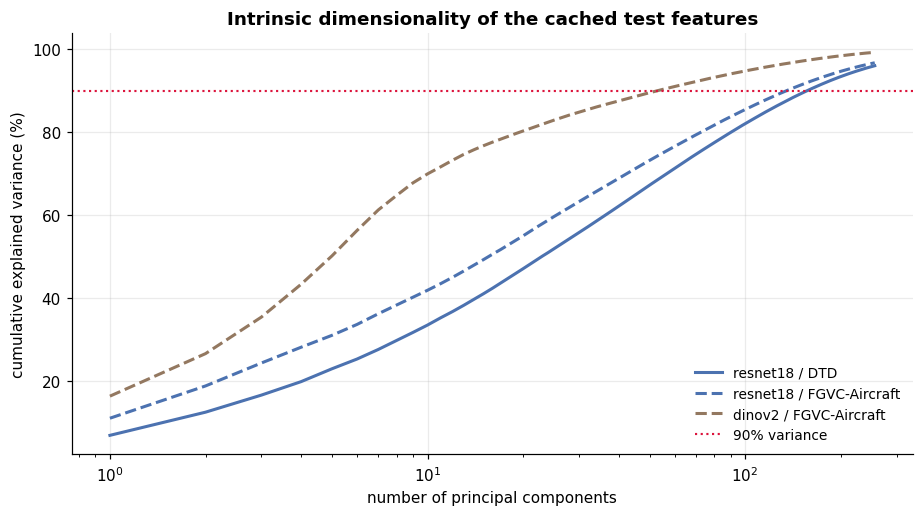

,encoder,dataset,feature_dim,components_fitted,components_for_50%,components_for_90%,components_for_95%,variance_at_fitted_%,top1_variance_%
0,resnet18,DTD,512,256,23,157,231,96.0,6.8
1,resnet18,FGVC-Aircraft,512,256,16,136,207,96.7,11.0
2,dinov2,FGVC-Aircraft,384,256,5,53,104,99.3,16.3


In [11]:
from sklearn.decomposition import PCA

def components_for(cumulative: np.ndarray, threshold: float, fitted: int):
    """Components needed to reach `threshold` of the variance.

    Returns a `">N"` string when the threshold is not reached within the components we
    fitted, rather than silently reporting `N+1` as though it were a real count.
    """
    idx = int(np.searchsorted(cumulative, threshold))
    return idx + 1 if idx < len(cumulative) else f">{fitted}"


pca_rows = []
curves: dict[str, np.ndarray] = {}

for enc, ds_name in COMBOS:
    x = feature_cache[(enc, ds_name, "test")].features.numpy()
    n_fitted = min(256, x.shape[1], x.shape[0])
    pca = PCA(n_components=n_fitted).fit(x)
    cumulative = np.cumsum(pca.explained_variance_ratio_)
    key = f"{enc} / {ds_name}"
    curves[key] = cumulative

    pca_rows.append({
        "encoder": enc, "dataset": ds_name,
        "feature_dim": x.shape[1],
        "components_fitted": n_fitted,
        "components_for_50%": components_for(cumulative, 0.50, n_fitted),
        "components_for_90%": components_for(cumulative, 0.90, n_fitted),
        "components_for_95%": components_for(cumulative, 0.95, n_fitted),
        "variance_at_fitted_%": round(100 * float(cumulative[-1]), 1),
        "top1_variance_%": round(100 * float(pca.explained_variance_ratio_[0]), 1),
    })

pca_df = pd.DataFrame(pca_rows)
art.table(pca_df, "pca_variance")

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for (key, cumulative), (enc, _) in zip(curves.items(), COMBOS):
    ax.plot(np.arange(1, len(cumulative) + 1), 100 * cumulative,
            label=key, color=ENCODER_COLORS[enc],
            ls="-" if "DTD" in key else "--", lw=2)
ax.axhline(90, color="crimson", ls=":", lw=1.4, label="90% variance")
ax.set_xlabel("number of principal components")
ax.set_ylabel("cumulative explained variance (%)")
ax.set_title("Intrinsic dimensionality of the cached test features")
ax.set_xscale("log")
ax.legend(fontsize=9)
fig.tight_layout()
art.figure(fig, "pca_explained_variance")
plt.show()
pca_df

## 8 · Class separability preview

A cheap, training-free diagnostic that predicts what steps 3 and 4 will find.

For each test image we L2-normalise its feature, compute the mean feature of each class,
and compare the cosine similarity to its **own** class mean against the mean similarity to
**all other** class means. The gap between them — the *separability margin* — measures how
much class structure the frozen representation already contains, before any classifier is
trained.

> **These accuracies are diagnostics and must not be quoted as results.** The centroids
> here are computed from the *test* features themselves, so the numbers are optimistically
> biased — every image contributed to the centroid it is then scored against. That is fine
> for the question being asked (*how much class structure does this representation
> contain?*) but it is not the prototype baseline. Step 4 implements the assignment's exact
> formula, building prototypes from the official **training** subsets and evaluating on the
> untouched test split. Expect step 4's numbers to be lower, and treat only those as
> reportable.

What is meaningful here is the **ranking** between the three combinations, which is not
affected by that bias since all three are computed identically.

  saved table -> tables/class_separability.csv  (3 rows)


  saved plot  -> plots/class_separability.png


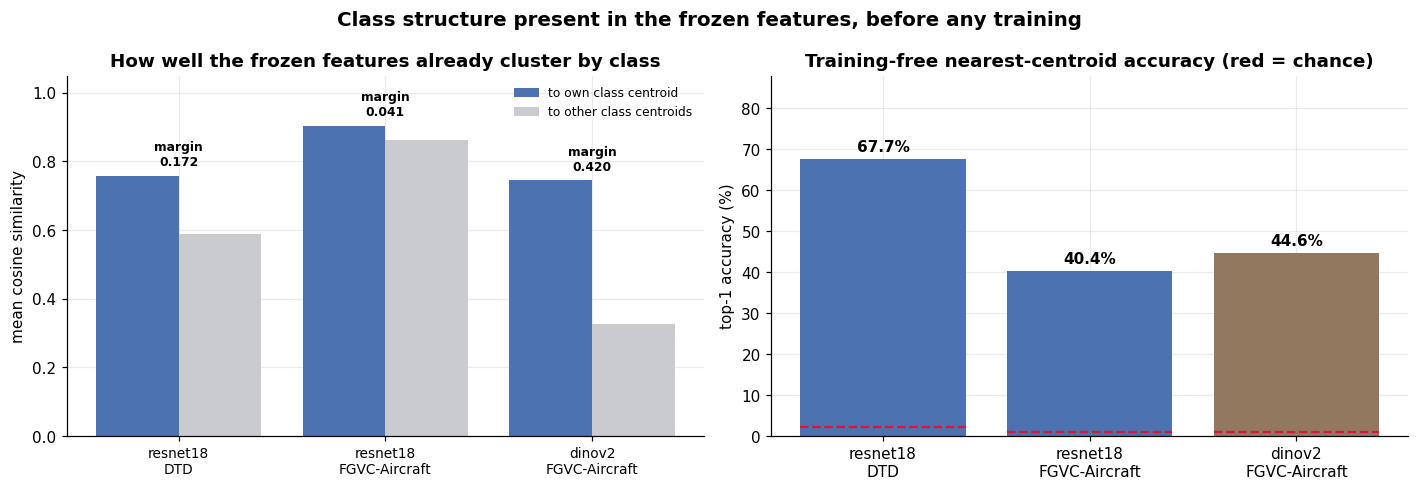

,encoder,dataset,n_classes,cos_to_own_class,cos_to_other_classes,separability_margin,nearest_centroid_acc_%
0,resnet18,DTD,47,0.7586,0.5871,0.1715,67.66
1,resnet18,FGVC-Aircraft,100,0.9034,0.8624,0.0411,40.35
2,dinov2,FGVC-Aircraft,100,0.7449,0.3248,0.4201,44.64


In [12]:
def separability(bundle) -> dict:
    """Mean cosine similarity to own class centroid vs. to other class centroids."""
    x = torch.nn.functional.normalize(bundle.features, dim=1)
    y = bundle.labels
    n_classes = bundle.n_classes

    centroids = torch.stack([
        torch.nn.functional.normalize(x[y == c].mean(dim=0), dim=0)
        for c in range(n_classes)
    ])

    sims = x @ centroids.T                                   # (N, C)
    own = sims[torch.arange(len(x)), y]                      # similarity to own centroid
    total = sims.sum(dim=1)
    other = (total - own) / (n_classes - 1)                  # mean over the other classes

    return {
        "cos_to_own_class": round(float(own.mean()), 4),
        "cos_to_other_classes": round(float(other.mean()), 4),
        "separability_margin": round(float((own - other).mean()), 4),
        "nearest_centroid_acc_%": round(100 * float((sims.argmax(1) == y).float().mean()), 2),
    }


sep_rows = []
for enc, ds_name in COMBOS:
    bundle = feature_cache[(enc, ds_name, "test")]
    sep_rows.append({"encoder": enc, "dataset": ds_name,
                     "n_classes": bundle.n_classes, **separability(bundle)})

sep_df = pd.DataFrame(sep_rows)
art.table(sep_df, "class_separability")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x_pos = np.arange(len(sep_df))
labels_x = [f"{r.encoder}\n{r.dataset}" for r in sep_df.itertuples()]

ax = axes[0]
ax.bar(x_pos - 0.2, sep_df["cos_to_own_class"], 0.4, label="to own class centroid",
       color="#4C72B0")
ax.bar(x_pos + 0.2, sep_df["cos_to_other_classes"], 0.4, label="to other class centroids",
       color="#C9CBCF")
for i, r in enumerate(sep_df.itertuples()):
    ax.annotate(f"margin\n{r.separability_margin:.3f}",
                (i, max(r.cos_to_own_class, r.cos_to_other_classes) + 0.03),
                ha="center", fontsize=8, fontweight="bold")
ax.set_xticks(x_pos); ax.set_xticklabels(labels_x, fontsize=9)
ax.set_ylabel("mean cosine similarity")
ax.set_title("How well the frozen features already cluster by class")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)

ax = axes[1]
bars = ax.bar(labels_x, sep_df["nearest_centroid_acc_%"],
              color=[ENCODER_COLORS[e] for e in sep_df["encoder"]])
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontweight="bold")
for i, r in enumerate(sep_df.itertuples()):
    chance = 100 / r.n_classes
    ax.hlines(chance, i - 0.4, i + 0.4, color="crimson", ls="--", lw=1.5)
ax.set_ylabel("top-1 accuracy (%)")
ax.set_title("Training-free nearest-centroid accuracy (red = chance)")
ax.set_ylim(0, max(sep_df["nearest_centroid_acc_%"]) * 1.3)

fig.suptitle("Class structure present in the frozen features, before any training",
             fontsize=13, fontweight="bold")
fig.tight_layout()
art.figure(fig, "class_separability")
plt.show()
sep_df

## 9 · Copyright-banner ablation

Step 01 found the banner and argued it should be cropped. This measures whether that
actually mattered, instead of leaving it as an untested assumption.

We re-extract a fixed subset of FGVC-Aircraft test images **without** the crop, using the
same encoder and the same image order, then compare the two feature sets directly:

- **Cosine similarity** between the cropped and un-cropped feature of the same image. A
  value near 1.0 would mean the banner barely perturbs the representation.
- **Nearest-centroid accuracy** on that subset both ways, as a task-level check.

Whatever the outcome, cropping stays: it is strictly more correct to feed the encoder the
photograph rather than the photograph plus a copyright notice. The point of measuring is to
know how large the effect is, and to be able to answer the question if asked.

    cropped    100%  batch 15/15  ~36 img/s


    uncropped  100%  batch 15/15  ~40 img/s


  saved table -> tables/banner_ablation.csv  (1 rows)


  saved plot  -> plots/banner_ablation.png


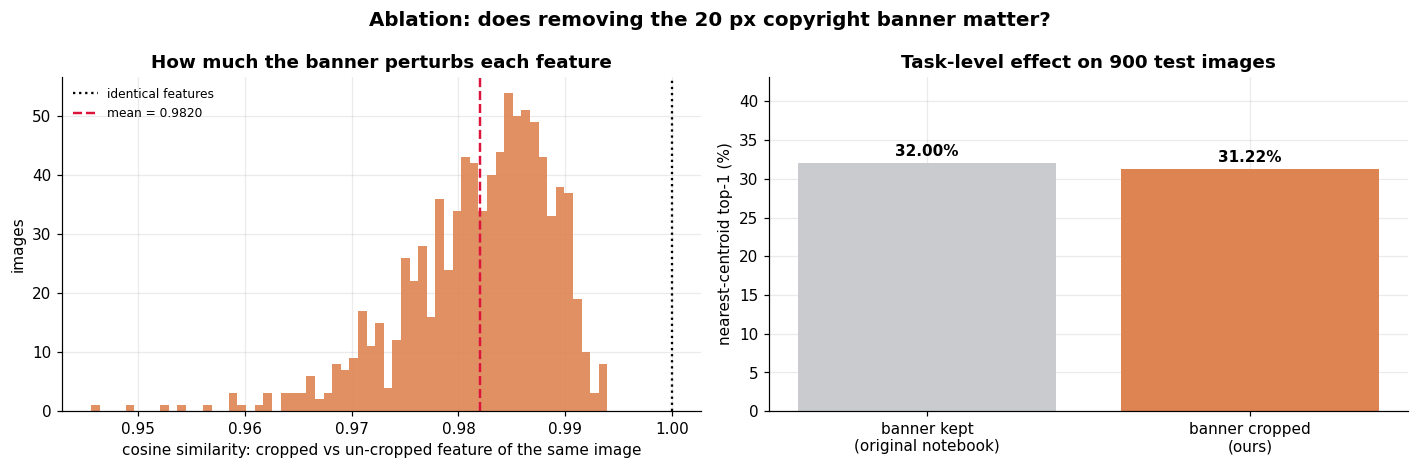

accuracy gap      : 0.78 pp  (7 images)
binomial SE (n=900): +/- 1.55 pp
=> the gap is WITHIN one standard error


,encoder,n_images,banner_px,cosine_mean,cosine_min,cosine_p5,rel_L2_change_mean_%,nn_centroid_acc_cropped_%,nn_centroid_acc_uncropped_%
0,resnet18,900,20,0.982,0.9456,0.9693,19.18,31.22,32.0


In [13]:
ABLATION_N = 900
ablation_encoder = "resnet18"

model = encoders[ablation_encoder]["model"]
base_tf = encoders[ablation_encoder]["transform"]

subset_idx = list(range(ABLATION_N))
ablation_features = {}

for crop_flag, tag in [(True, "cropped"), (False, "uncropped")]:
    tf = preprocessing_for(base_tf, "FGVC-Aircraft", crop_banner=crop_flag)
    ds = torch.utils.data.Subset(load_split("FGVC-Aircraft", "test", transform=tf), subset_idx)
    feats, labs, elapsed = extract_features(
        model, ds, device=DEVICE, batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS, progress_every=1.0, label=f"{tag:9s} ",
    )
    ablation_features[tag] = (feats, labs)

model.cpu()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

f_crop, y_sub = ablation_features["cropped"]
f_nocrop, _ = ablation_features["uncropped"]

cos = torch.nn.functional.cosine_similarity(f_crop, f_nocrop, dim=1)
rel_change = (f_crop - f_nocrop).norm(dim=1) / f_nocrop.norm(dim=1)


def nearest_centroid_acc(feats, labs) -> float:
    x = torch.nn.functional.normalize(feats, dim=1)
    present = torch.unique(labs)
    centroids = torch.stack([
        torch.nn.functional.normalize(x[labs == c].mean(dim=0), dim=0) for c in present
    ])
    pred = present[(x @ centroids.T).argmax(1)]
    return 100 * float((pred == labs).float().mean())


ablation_df = pd.DataFrame([{
    "encoder": ablation_encoder,
    "n_images": ABLATION_N,
    "banner_px": AIRCRAFT_BANNER_PX,
    "cosine_mean": round(float(cos.mean()), 4),
    "cosine_min": round(float(cos.min()), 4),
    "cosine_p5": round(float(cos.kthvalue(max(1, int(0.05 * len(cos)))).values), 4),
    "rel_L2_change_mean_%": round(100 * float(rel_change.mean()), 2),
    "nn_centroid_acc_cropped_%": round(nearest_centroid_acc(f_crop, y_sub), 2),
    "nn_centroid_acc_uncropped_%": round(nearest_centroid_acc(f_nocrop, y_sub), 2),
}])
art.table(ablation_df, "banner_ablation")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

ax = axes[0]
ax.hist(cos.numpy(), bins=60, color=DATASET_COLORS["FGVC-Aircraft"], alpha=0.9)
ax.axvline(1.0, color="black", ls=":", lw=1.5, label="identical features")
ax.axvline(float(cos.mean()), color="crimson", ls="--", lw=1.6,
           label=f"mean = {cos.mean():.4f}")
ax.set_xlabel("cosine similarity: cropped vs un-cropped feature of the same image")
ax.set_ylabel("images")
ax.set_title("How much the banner perturbs each feature")
ax.legend(fontsize=8)

ax = axes[1]
accs = [ablation_df["nn_centroid_acc_uncropped_%"].iloc[0],
        ablation_df["nn_centroid_acc_cropped_%"].iloc[0]]
bars = ax.bar(["banner kept\n(original notebook)", "banner cropped\n(ours)"], accs,
              color=["#C9CBCF", DATASET_COLORS["FGVC-Aircraft"]])
ax.bar_label(bars, fmt="%.2f%%", padding=3, fontweight="bold")
ax.set_ylabel("nearest-centroid top-1 (%)")
ax.set_title(f"Task-level effect on {ABLATION_N} test images")
ax.set_ylim(0, max(accs) * 1.35)

fig.suptitle(f"Ablation: does removing the {AIRCRAFT_BANNER_PX} px copyright banner matter?",
             fontsize=13, fontweight="bold")
fig.tight_layout()
art.figure(fig, "banner_ablation")
plt.show()

# Binomial standard error, to judge whether the accuracy gap means anything at all.
p = ablation_df["nn_centroid_acc_uncropped_%"].iloc[0] / 100
se_pp = 100 * (p * (1 - p) / ABLATION_N) ** 0.5
gap_pp = abs(ablation_df["nn_centroid_acc_cropped_%"].iloc[0]
             - ablation_df["nn_centroid_acc_uncropped_%"].iloc[0])
print(f"accuracy gap      : {gap_pp:.2f} pp  ({round(gap_pp / 100 * ABLATION_N)} images)")
print(f"binomial SE (n={ABLATION_N}): +/- {se_pp:.2f} pp")
print(f"=> the gap is {'WITHIN' if gap_pp < se_pp else 'OUTSIDE'} one standard error")
ablation_df

### Result: the banner does not matter, and we should say so

The measurement does **not** support the enthusiasm this crop was introduced with in step 01.

- Cropped and un-cropped features of the same image have mean cosine similarity **0.982**.
  The direction of the feature — the only thing cosine classifiers and a learned linear map
  actually respond to — is essentially unchanged.
- The task-level difference is **0.78 pp on 900 images**, about seven images, which is
  smaller than the binomial standard error of roughly ±1.6 pp. It is noise. It also happens
  to point in the *opposite* direction from the one predicted: the cropped version scored
  marginally lower.

So: step 01 was right that the banner exists, right that it survives into the 224×224 crop,
and **wrong to imply it was materially damaging results**. It is not.

**We keep the crop anyway**, for one reason only: it is more correct to feed the encoder the
photograph rather than the photograph plus a copyright notice, and it costs nothing. But it
should be presented as hygiene, not as an improvement — and if asked "how much did that
help?", the honest answer is *"nothing measurable, and here is the ablation that shows it"*.

Being able to say that is worth more than the crop itself. An untested assumption that
sounds plausible is exactly the kind of thing that quietly becomes folklore in a project.

## 10 · Artefact manifest

In [14]:
art.manifest()

print()
print("Feature cache written to", FEATURES_ROOT)
for p in sorted(FEATURES_ROOT.glob("*.pt")):
    print(f"  {p.name:45s} {p.stat().st_size / 1024 ** 2:6.1f} MB")

14 artefacts in C:\Users\youse\Project in Computer Vision\ProjectInComputerVision\Stage_1\Work\02_feature_extraction

Feature cache written to C:\Users\youse\Project in Computer Vision\ProjectInComputerVision\Stage_1\features
  dinov2__fgvc_aircraft__test.pt                   4.9 MB
  dinov2__fgvc_aircraft__train.pt                  4.9 MB
  dinov2__fgvc_aircraft__val.pt                    4.9 MB
  resnet18__dtd__test.pt                           3.7 MB
  resnet18__dtd__train.pt                          3.7 MB
  resnet18__dtd__val.pt                            3.7 MB
  resnet18__fgvc_aircraft__test.pt                 6.5 MB
  resnet18__fgvc_aircraft__train.pt                6.5 MB
  resnet18__fgvc_aircraft__val.pt                  6.5 MB


---

## Summary

Nine feature caches written and verified. From here the encoders are never loaded again.

**Requirements satisfied**

| Requirement (`stage_1.pdf`) | Status |
|---|---|
| All encoder parameters frozen | asserted in `build_encoder`, verified in §1 |
| ResNet-18, 512-d, before the final classification layer | `fc = Identity`, dimension verified |
| DINOv2 ViT-S/14, final CLS token, 384-d | verified |
| ResNet-18 on both datasets; DINOv2 on one | 3 combinations |
| Preprocessing associated with each checkpoint | `weights.transforms()` / DINOv2 eval recipe |
| Features cached before any classifier training | 9 files in `Stage_1/features/` |

**The single most useful number in this notebook**

§8 explains, quantitatively and before any training, *why* ResNet-18 struggles on Aircraft:

| Combination | cos to own class | cos to other classes | margin |
|---|---|---|---|
| ResNet-18 / DTD | 0.759 | 0.587 | **0.172** |
| ResNet-18 / FGVC-Aircraft | 0.903 | 0.862 | **0.041** |
| DINOv2 / FGVC-Aircraft | 0.745 | 0.325 | **0.420** |

In ResNet-18's feature space every aircraft is similar to every other aircraft — 0.862 mean
cosine similarity to the *wrong* classes. The representation has collapsed the whole dataset
into a narrow cone labelled roughly "airliner", leaving a margin of 0.041 for a classifier
to work with. DINOv2 spreads the same 100 classes over a margin ten times wider.

That is the mechanism behind the accuracy gap steps 3 and 4 will measure, and it is visible
here without fitting anything. It also makes this section a regression test: if step 3 does
*not* rank the three combinations in this order, the bug is in the classifier code, not in
the features.

**Remember §6 when you get to step 5.** Feature norms are ~23.6 (ResNet/DTD), ~28.9
(ResNet/Aircraft) and ~49.7 (DINOv2/Aircraft) — all far from unit norm, and differing
between encoders by roughly 2x. Any visualisation that plots raw features together with
unit-norm prototypes will show the prototypes collapsed into a single blob near the origin,
no matter what the data actually looks like. Normalise first.

**And note what §9 found.** The copyright-banner crop, introduced with some confidence in
step 01, turns out to make no measurable difference (cosine 0.982, accuracy gap 0.78 pp
against a ±1.6 pp standard error). It stays because it is correct hygiene, not because it
helps.

### Next

**Step 3 — Linear probe.** Train `s = Wz + b` on the cached features: 3 encoder-dataset
pairs × K ∈ {5, 10, full} × 3 seeds = 27 runs, with AdamW, lr 1e-3, weight decay 1e-4,
batch size 64, up to 200 epochs, checkpointing on best validation accuracy. Because it reads
cached vectors, the whole sweep costs minutes.

The k-shot sampler it needs already exists in `cvlab.data.make_kshot_subset`, so step 4's
prototype baseline will draw **identical** subsets for a given `(K, seed)` — which is what
makes the two baselines directly comparable.